In [23]:
%load_ext autoreload

%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import seaborn as sns   
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from lifelines import CoxPHFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
from lifelines import KaplanMeierFitter
from lifelines.statistics import pairwise_logrank_test
from lifelines.plotting import add_at_risk_counts
import warnings
from preproces_prod4_2025_update import *
from scipy.stats import norm
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from matching_case_control import match_nn_max_dist_weigths
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")


pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

In [ ]:
df_pf = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv')

_, _, df_f_vrs_tramos_final, _ = filtros_IH_new(df_pf,
                                          eliminar_inmunes_pre_season=False, 
                                          fecha_cohort_in = pd.to_datetime('2023-10-01'),
                                          fecha_cohort_out = pd.to_datetime('2025-09-30'),
                                          T_inicial = pd.to_datetime('2025-03-01'), 
                                          fecha_dt = pd.to_datetime('2025-09-30'),
                                          duracion_dias_nirse=180,
                                          meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                          ef_2024_in_2025=True)

In [21]:
df_pf = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv')

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025


In [86]:
df_leo = filtros_IH_simple(df_pf,
                           fecha_cohort_in = pd.to_datetime('2023-10-01'),
                           fecha_cohort_out = pd.to_datetime('2025-10-01'),
                           T_inicial = pd.to_datetime('2024-03-01'), 
                           fecha_dt = pd.to_datetime('2025-08-30'))

Datos perdidos por muertes:  2520
ruts perdidos por filtro semanas y peso:  1085
Droped intersex: 28
Datos perdidos por edad madre atípica: 477
Datos perdidos por fecha ingreso menor a fecha nacimiento: 31
vrs en los primeros 7 dias de nacer: 4
Ruts eliminados: 7184
fechaIng_vrs Reemplazos n/a net 7 days inmunizado:  34


In [91]:
fecha_in = pd.to_datetime('2023-10-01')
fecha_out = pd.to_datetime('2024-09-30')
df_leo.query('eleg_2025=="no_elegible_2025"').shape[0], df_leo.query('@fecha_in <= fecha_nac <= @fecha_out').shape[0]

(172945, 172945)

In [84]:
df_leo.query('inmunizado==0').RUN.nunique()

8883

In [92]:
ruts_ambos_anios = (
    df_leo
    .query('inmunizado == 0 and event_vrs == 1')
    .assign(ano_ing=lambda x: x.fechaIng_vrs.dt.year)
    .query('ano_ing in [2024, 2025]')
    .groupby('RUN')['ano_ing']
    .nunique()
    .loc[lambda x: x == 2]
)

cantidad = len(ruts_ambos_anios)
print('dobles',cantidad)

ruts_ambos_anios = (
    df_leo
    .query('inmunizado == 0 and event_vrs == 1')
    .assign(ano_ing=lambda x: x.fechaIng_vrs.dt.year)
    .query('ano_ing in [2025]')
    .groupby('RUN')['ano_ing']
    .nunique()
    .loc[lambda x: x == 1]
)

cantidad = len(ruts_ambos_anios)
print('simples',cantidad)


dobles 5
simples 241


In [67]:
ruts_ambos_anios = (
    df_leo
    .query('inmunizado == 0 and event_vrs == 1')
    .assign(
        ano_ing=lambda x: x.fechaIng_vrs.dt.year,
        mes_ing_name=lambda x: x.fechaIng_vrs.dt.month_name(),
        in_season_event=lambda x: x.fechaIng_vrs.dt.month.isin([4,5,6,7,8,9])
    )
    .query('ano_ing in [2024, 2025] and in_season_event')
    .groupby('RUN')['ano_ing']
    .nunique()
    .loc[lambda x: x == 2]
)

cantidad = len(ruts_ambos_anios)
cantidad

4

In [ ]:
df_cox_vrs_tramos_2year_v2, _, df_f_vrs_tramos_2year_v2, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2024',
                                                        fecha_cohort_in = pd.to_datetime('2023-10-01'),
                                                        fecha_cohort_out = pd.to_datetime('2025-09-30'),
                                                        T_inicial = pd.to_datetime('2024-04-01'), 
                                                        fecha_dt = pd.to_datetime('2025-09-30'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                                        meses_inm_bool=True,
                                                        ef_2024_in_2025=True)

df_cox_vrs_tramos_2year_mod_v2 = df_cox_vrs_tramos_2year_v2.copy()

cols = [f"inm_mayor_{k}_meses" for k in range(17)]  # 0..5

# matriz booleana (trata NaN como 0)
M = df_cox_vrs_tramos_2year_mod_v2[cols].fillna(0).astype(int).to_numpy().astype(bool)

# buscar la columna activa de mayor k: invierto columnas y tomo el primer True
M_rev = M[:, ::-1]
has_any = M_rev.any(axis=1)
pos_rev = M_rev.argmax(axis=1)          # índice del primer True en el orden invertido (0..5)
k_max = (len(cols) - 1) - pos_rev       # convertir a k real (0..5)
k_max[~has_any] = -1                    # filas sin ningún 1

# construir la nueva matriz one-hot
newM = np.zeros_like(M, dtype=int)
rows = np.arange(M.shape[0])
mask = k_max >= 0
newM[rows[mask], k_max[mask]] = 1

# escribir de vuelta al df (sobrescribe esas columnas)
df_cox_vrs_tramos_2year_mod_v2.loc[:, cols] = newM

df_f_vrs_tramos_2year_v2 = df_f_vrs_tramos_2year_v2.drop(columns=[col for col in df_f_vrs_tramos_2year_v2.columns if 
                                                            col.startswith('AREA') | 
                                                            col.startswith('DIA_') | 
                                                            col.startswith('SERC_') | 
                                                            col.endswith('_TRAS') | 
                                                            col.startswith('dias_en_a')]).copy()

df_cox_vrs_tramos_2year_v2.to_csv(path_data/'df_cox_vrs_tramos_2year_v2.csv')
df_cox_vrs_tramos_2year_mod_v2.to_csv(path_data/'df_cox_vrs_tramos_2year_mod_v2.csv')
df_f_vrs_tramos_2year_v2.to_csv(path_data/'df_f_vrs_tramos_2year_v2.csv')


n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  2536
ruts perdidos por filtro semanas y peso:  1130
Droped intersex: 28
Datos perdidos por edad madre atípica: 483
Datos perdidos por fecha ingreso menor a fecha nacimiento: 31
vrs en los primeros 7 dias 

In [127]:
df_pf.to_csv(path_data/'df_pf_12_03_2026.csv')

In [10]:
covs = ['start', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','year_nac']
columns_inm = [col for col in df_cox_vrs_tramos_2year_mod_v2.columns if col.endswith('_meses')]
df_cox = df_cox_vrs_tramos_2year_mod_v2.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo','year_nac']
ctv_0.fit(df_cox[covs + columns_inm], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_0_meses,0.775821,0.730049,0.813832,0.000000,-1.495308,0.094795,-1.681104,-1.309513
inm_mayor_1_meses,0.656091,0.600543,0.703915,0.000000,-1.067378,0.076394,-1.217109,-0.917648
inm_mayor_2_meses,0.709798,0.661868,0.750934,0.000000,-1.237178,0.077991,-1.390037,-1.084320
inm_mayor_3_meses,0.717066,0.665788,0.760476,0.000000,-1.262541,0.084981,-1.429100,-1.095981
inm_mayor_4_meses,0.665480,0.595345,0.723459,0.000000,-1.095058,0.097113,-1.285395,-0.904721
inm_mayor_5_meses,0.547530,0.421912,0.645851,0.000000,-0.793033,0.125004,-1.038038,-0.548029
inm_mayor_6_meses,0.571153,0.369413,0.708351,0.000017,-0.846655,0.196713,-1.232205,-0.461104
inm_mayor_7_meses,0.367071,-0.074639,0.627225,0.090370,-0.457398,0.270098,-0.986781,0.071985
inm_mayor_8_meses,0.518958,0.186214,0.715648,0.006369,-0.731800,0.268241,-1.257542,-0.206058


In [207]:
results_ppt = printSummary(ctv_0)
results_ppt['VE [CI]'] = (results_ppt.effectiveness.round(3).astype(str) + 
                          ' [' + results_ppt.eff_lower_95.round(3).astype(str) + ', ' + 
                          results_ppt.eff_upper_95.round(3).astype(str)+   ']')

results_ppt[['VE [CI]','p','coef','se(coef)']]

,VE [CI],p,coef,se(coef)
covariate,,,,
inm_mayor_0_meses,"0.776 [0.73, 0.814]",0.000000,-1.495308,0.094795
inm_mayor_1_meses,"0.656 [0.601, 0.704]",0.000000,-1.067378,0.076394
inm_mayor_2_meses,"0.71 [0.662, 0.751]",0.000000,-1.237178,0.077991
inm_mayor_3_meses,"0.717 [0.666, 0.76]",0.000000,-1.262541,0.084981
inm_mayor_4_meses,"0.665 [0.595, 0.723]",0.000000,-1.095058,0.097113
inm_mayor_5_meses,"0.548 [0.422, 0.646]",0.000000,-0.793033,0.125004
inm_mayor_6_meses,"0.571 [0.369, 0.708]",0.000017,-0.846655,0.196713
inm_mayor_7_meses,"0.367 [-0.075, 0.627]",0.090370,-0.457398,0.270098
inm_mayor_8_meses,"0.519 [0.186, 0.716]",0.006369,-0.731800,0.268241


In [11]:
orden_meses = ['October','November','December','January','February','March','April','May','June','July','August','September']

tabla_a = (df_cox_vrs_tramos_2year_mod_v2
           .groupby('RUN',as_index=False)
           .agg({'inmunizado':'max','mes_nac_name':'first','year_nac':'first'})           
           .groupby(['inmunizado','mes_nac_name','year_nac'])
           .RUN.nunique()
           .unstack(['year_nac','inmunizado'])
           .fillna(0.001)
           .assign(n_2023 = lambda x: x[(2023, 1.0)].astype(int).astype(str) + '/' + x[(2023, 0.0)].astype(int).astype(str),
           n_2024 = lambda x: x[(2024, 1.0)].astype(int).astype(str) + '/' + x[(2024, 0.0)].astype(int).astype(str),
           n_2025 = lambda x: x[(2025, 1.0)].astype(int).astype(str) + '/' + x[(2025, 0.0)].astype(int).astype(str))
           [['n_2023','n_2024','n_2025']]
           .rename(columns={'n_2023':'2023: imm/no_imm','n_2024':'2024: imm/no_imm','n_2025':'2025: imm/no_imm'})
           .droplevel(1, axis=1)
           .replace('0/0', '-')
           .reindex(orden_meses)
)
tabla_a

year_nac,2023: imm/no_imm,2024: imm/no_imm,2025: imm/no_imm
mes_nac_name,,,
October,11474/1923,11988/135,-
November,11439/1386,10925/507,-
December,12105/1027,11339/586,-
January,-,12913/1006,12093/497
February,-,11911/836,10908/361
March,-,12790/764,12209/135
April,-,13028/264,12111/192
May,-,12722/223,12036/172
June,-,11884/227,11126/172


In [12]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac']  # 

df_tv = df_cox_vrs_tramos_2year_mod_v2.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

1:1 ['1', '1']
here aaa
Total cases = 12063, Total controls = 283048
Total cases matched is : 12062, Total control matched is : 12062
ratio: 1:1
No matched : 1


In [ ]:
(df_tv_matched
 .merge(df_f_vrs_tramos_2year_v2[['RUN','fechaInm']],on='RUN',how='left')
 .to_csv(path_data/'df_tv_matched_11_03_2026.csv',index=False)
 )

In [219]:
df_tv_matched.columns

Index(['RUN', 'stop', 'event_vrs', 'start', 'inmunizado', 'inm_mayor_0_meses',
       'inm_mayor_1_meses', 'inm_mayor_2_meses', 'inm_mayor_3_meses',
       'inm_mayor_4_meses', 'inm_mayor_5_meses', 'inm_mayor_6_meses',
       'inm_mayor_7_meses', 'inm_mayor_8_meses', 'inm_mayor_9_meses',
       'inm_mayor_10_meses', 'inm_mayor_11_meses', 'inm_mayor_12_meses',
       'inm_mayor_13_meses', 'inm_mayor_14_meses', 'inm_mayor_15_meses',
       'inm_mayor_16_meses', 'group', 'eleg_2025', 'eleg_2024', 'eleg_group',
       'sexo', 'prematuro_extremo', 'muy_prematuro', 'prematuro_moderado',
       'prematuro', 'region', 'Macrozona2', 'EDAD_M', 'INS_C_M', 'REG_RES',
       'DIAG1', 'MARCA', 'PREVI', 'DIAG2', 'DIAG3', 'DIAG4', 'DIAG5', 'DIAG6',
       'DIAG7', 'DIAG8', 'DIAG9', 'DIAG10', 'DIAG11', 'URBA_RURAL', 'COMUNA',
       'COMUNA_N', 'atypic_mom_age', 'INS_N_M', 'SEMANAS', 'semana_nac',
       'mes_nac_name', 'year_nac', 'cama', 'is_rural', 'categori_macro',
       'categori_regions', 'exp_r

In [208]:
ctv = CoxTimeVaryingFitter()
ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group"]+[f'inm_mayor_{k}_meses' for k in range(17)]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 8.47e-01, step_size = 0.9500, log_lik = -535.10962, newton_decrement = 1.35e+02, seconds_since_start = 20.8
Iteration 2: norm_delta = 2.55e-01, step_size = 0.9500, log_lik = -391.52782, newton_decrement = 8.36e+00, seconds_since_start = 32.9
Iteration 3: norm_delta = 8.90e-02, step_size = 0.9500, log_lik = -382.33103, newton_decrement = 6.11e-01, seconds_since_start = 40.3
Iteration 4: norm_delta = 1.80e-02, step_size = 1.0000, log_lik = -381.68549, newton_decrement = 1.63e-02, seconds_since_start = 47.5
Iteration 5: norm_delta = 5.40e-04, step_size = 1.0000, log_lik = -381.66885, newton_decrement = 1.33e-05, seconds_since_start = 54.7
Iteration 6: norm_delta = 5.13e-07, step_size = 1.0000, log_lik = -381.66884, newton_decrement = 1.20e-11, seconds_since_start = 62.1
Convergence completed after 6 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_0_meses,0.936170,0.854305,0.972036,0.000000,-2.751535,0.421076,-3.576828,-1.926242
inm_mayor_1_meses,0.846154,0.729944,0.912357,0.000000,-1.871802,0.287085,-2.434478,-1.309127
inm_mayor_2_meses,0.811111,0.682818,0.887512,0.000000,-1.666596,0.264452,-2.184912,-1.148281
inm_mayor_3_meses,0.894118,0.789525,0.946735,0.000000,-2.245427,0.350536,-2.932466,-1.558388
inm_mayor_4_meses,0.722222,0.440283,0.862144,0.000339,-1.280934,0.357460,-1.981543,-0.580325
inm_mayor_5_meses,0.454545,-0.474890,0.798276,0.232356,-0.606136,0.507519,-1.600855,0.388584
inm_mayor_6_meses,-0.500000,-7.976942,0.749358,0.656923,0.405465,0.912871,-1.383729,2.194659
inm_mayor_7_meses,0.500000,-4.514101,0.954662,0.571426,-0.693147,1.224745,-3.093603,1.707309
inm_mayor_8_meses,0.000000,-14.987508,0.937451,1.000000,-0.000000,1.414214,-2.771808,2.771808


In [209]:
results_ppt = printSummary(ctv)
results_ppt['VE [CI]'] = (results_ppt.effectiveness.round(3).astype(str) + 
                          ' [' + results_ppt.eff_lower_95.round(3).astype(str) + ', ' + 
                          results_ppt.eff_upper_95.round(3).astype(str)+   ']')

results_ppt[['VE [CI]','p','coef','se(coef)']]

,VE [CI],p,coef,se(coef)
covariate,,,,
inm_mayor_0_meses,"0.936 [0.854, 0.972]",0.000000,-2.751535,0.421076
inm_mayor_1_meses,"0.846 [0.73, 0.912]",0.000000,-1.871802,0.287085
inm_mayor_2_meses,"0.811 [0.683, 0.888]",0.000000,-1.666596,0.264452
inm_mayor_3_meses,"0.894 [0.79, 0.947]",0.000000,-2.245427,0.350536
inm_mayor_4_meses,"0.722 [0.44, 0.862]",0.000339,-1.280934,0.357460
inm_mayor_5_meses,"0.455 [-0.475, 0.798]",0.232356,-0.606136,0.507519
inm_mayor_6_meses,"-0.5 [-7.977, 0.749]",0.656923,0.405465,0.912871
inm_mayor_7_meses,"0.5 [-4.514, 0.955]",0.571426,-0.693147,1.224745
inm_mayor_8_meses,"0.0 [-14.988, 0.937]",1.000000,-0.000000,1.414214


In [148]:
ctv = CoxTimeVaryingFitter()
ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group"]+[f'inm_mayor_{k}_meses' for k in range(17)]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv).round(3))

Iteration 1: norm_delta = 8.47e-01, step_size = 0.9500, log_lik = -535.10962, newton_decrement = 1.35e+02, seconds_since_start = 22.7
Iteration 2: norm_delta = 2.55e-01, step_size = 0.9500, log_lik = -391.52782, newton_decrement = 8.36e+00, seconds_since_start = 43.0
Iteration 3: norm_delta = 8.90e-02, step_size = 0.9500, log_lik = -382.33103, newton_decrement = 6.11e-01, seconds_since_start = 63.0
Iteration 4: norm_delta = 1.80e-02, step_size = 1.0000, log_lik = -381.68549, newton_decrement = 1.63e-02, seconds_since_start = 83.0
Iteration 5: norm_delta = 5.40e-04, step_size = 1.0000, log_lik = -381.66885, newton_decrement = 1.33e-05, seconds_since_start = 103.4
Iteration 6: norm_delta = 5.13e-07, step_size = 1.0000, log_lik = -381.66884, newton_decrement = 1.20e-11, seconds_since_start = 123.1
Convergence completed after 6 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_0_meses,0.936,0.854,0.972,0.000,-2.752,0.421,-3.577,-1.926
inm_mayor_1_meses,0.846,0.730,0.912,0.000,-1.872,0.287,-2.434,-1.309
inm_mayor_2_meses,0.811,0.683,0.888,0.000,-1.667,0.264,-2.185,-1.148
inm_mayor_3_meses,0.894,0.790,0.947,0.000,-2.245,0.351,-2.932,-1.558
inm_mayor_4_meses,0.722,0.440,0.862,0.000,-1.281,0.357,-1.982,-0.580
inm_mayor_5_meses,0.455,-0.475,0.798,0.232,-0.606,0.508,-1.601,0.389
inm_mayor_6_meses,-0.500,-7.977,0.749,0.657,0.405,0.913,-1.384,2.195
inm_mayor_7_meses,0.500,-4.514,0.955,0.571,-0.693,1.225,-3.094,1.707
inm_mayor_8_meses,0.000,-14.988,0.937,1.000,-0.000,1.414,-2.772,2.772


In [14]:
df_tv_matched_2 = (df_tv_matched
                   [~(df_tv_matched.RUN.isin(df_tv_matched.query('inm_mayor_13_meses==1').RUN.unique()))]
                   .copy())

df_tv_matched_2['inm_mayor_meses_agg_0_2'] = df_tv_matched_2[["inm_mayor_0_meses" ,'inm_mayor_1_meses','inm_mayor_2_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_3_5'] = df_tv_matched_2[["inm_mayor_3_meses" ,'inm_mayor_4_meses','inm_mayor_5_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_mas_de_6'] = df_tv_matched_2[[f'inm_mayor_{k}_meses' for k in range(6,17)]].sum(axis=1)

columns_inm = ['inm_mayor_meses_agg_0_2','inm_mayor_meses_agg_3_5','inm_mayor_meses_agg_mas_de_6'] #inm_mayor_meses_agg_6

ctv = CoxTimeVaryingFitter()

ctv.fit(
    df_tv_matched_2[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 5.17e-01, step_size = 0.9500, log_lik = -208.63730, newton_decrement = 1.78e+01, seconds_since_start = 7.0
Iteration 2: norm_delta = 6.00e-02, step_size = 0.9500, log_lik = -190.49171, newton_decrement = 1.95e-01, seconds_since_start = 14.1
Iteration 3: norm_delta = 4.41e-03, step_size = 0.9500, log_lik = -190.29505, newton_decrement = 9.52e-04, seconds_since_start = 21.3
Iteration 4: norm_delta = 2.41e-04, step_size = 1.0000, log_lik = -190.29410, newton_decrement = 2.54e-06, seconds_since_start = 28.3
Iteration 5: norm_delta = 2.68e-08, step_size = 1.0000, log_lik = -190.29410, newton_decrement = 2.45e-14, seconds_since_start = 35.8
Convergence completed after 5 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_meses_agg_0_2,0.588889,0.397176,0.719632,0.000005,-0.888892,0.195290,-1.271653,-0.506131
inm_mayor_meses_agg_3_5,0.456522,0.115530,0.666050,0.014126,-0.609766,0.248474,-1.096765,-0.122766
inm_mayor_meses_agg_mas_de_6,-1.875000,-5.427216,-0.286035,0.010087,1.056053,0.410461,0.251564,1.860542


In [ ]:
############################################################### CREACION DF COMPLETO ################################################################
meses = list(range(0, 17))  # 0..16
EVENT_COL = "event_vrs"
EV_DATE   = "fechaIng_vrs"
INM_DATE  = "fechaInm"

df = (df_f_vrs_tramos_2year_v2
      .assign(year_nac = lambda x: x.fecha_nac.dt.year,
              edad_relative = lambda x: x.fecha_nac - pd.to_datetime('2023-10-01'))
      [['RUN','fecha_nac','mes_nac_name','semana_nac',
        'SEMANAS','PESO','prematuro_extremo', 'muy_prematuro', 'prematuro_moderado', 'prematuro',
        'sexo','region','year_nac','eleg_group','eleg_2025','eleg_2024', 'MARCA', 'edad_relative',
        'event_vrs','fechaIng_vrs','fechaInm','inmunizado'] +
       [col for col in df_f_vrs_tramos_2year_v2.columns if col.startswith('inm_')]]
      .copy())

# Asegurar datetime
df[EV_DATE]  = pd.to_datetime(df[EV_DATE], errors="coerce")
df[INM_DATE] = pd.to_datetime(df[INM_DATE], errors="coerce")

# Eventos válidos
mask_event = df[EVENT_COL].eq(1) & df[EV_DATE].notna()

# Inicializa columna
df["evento_when_inmu"] = pd.NA

# Casos con evento pero sin fechaInm -> "never_inm"
mask_event_never = mask_event & df[INM_DATE].isna()
df.loc[mask_event_never, "evento_when_inmu"] = "never_inm"

# Casos con evento y con fechaInm
mask_event_has_inm = mask_event & df[INM_DATE].notna()

# Umbrales: fechaInm + m meses (m=0..16)  => matriz n x 17
thr = np.column_stack([
    (df.loc[mask_event_has_inm, INM_DATE] + pd.DateOffset(months=m)).to_numpy(dtype="datetime64[ns]")
    for m in meses
])

ev = df.loc[mask_event_has_inm, EV_DATE].to_numpy(dtype="datetime64[ns]")

# months_idx = #umbrales cumplidos - 1
# -1 => evento antes de inmunizarse
ge = ev[:, None] >= thr
m_idx = ge.sum(axis=1) - 1

# Etiquetas
labels = np.array([f"inm_{m}_meses" for m in meses], dtype=object)

evento_labels = np.where(
    m_idx < 0,
    "pre_inm",                       # evento ocurrió antes de fechaInm
    labels[np.clip(m_idx, 0, len(meses)-1)]  # si pasa de 16, lo dejamos como inm_16_meses
)

df.loc[mask_event_has_inm, "evento_when_inmu"] = evento_labels

# (opcional) ordenar categoría para tablas bonitas
ordered = ["never_inm", "pre_inm"] + [f"inm_{m}_meses" for m in meses]
df["evento_when_inmu"] = pd.Categorical(df["evento_when_inmu"], categories=ordered, ordered=True)

mask = df["inmunizado"].eq(1) & df["event_vrs"].eq(1) & df["fechaIng_vrs"].notna()

# create output column
df["k_window_event"] = np.nan

# assign k where fechaIng_vrs in [inm_k, inm_{k+1})
for k in range(16):
    s, e = f"inm_{k}_meses", f"inm_{k+1}_meses"
    if s not in df.columns or e not in df.columns:
        if k==16:
            cond_k = (
                mask
                & df[s].notna()
                & df["fechaIng_vrs"].ge(df[s])
            )
            df.loc[cond_k, "k_window_event"] = k
            continue
        else:
            continue

    cond_k = (
        mask
        & df[s].notna() & df[e].notna()
        & df["fechaIng_vrs"].ge(df[s])
        & df["fechaIng_vrs"].lt(df[e])   # [start, end)
    )
    df.loc[cond_k, "k_window_event"] = k

# (optional) if you want an integer dtype with missing values
df["k_window_event"] = df["k_window_event"].astype("Int64")

for k in range(1,17):
    df.loc[(df[f'inm_{k}_meses']>=df.fechaIng_vrs), f'inm_mayor_{k}_meses'] = -1


In [ ]:
df.to_csv(path_data/'df_f_vrs_denis_ratio.csv')

In [128]:
list_k = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
rows_2=[]
dfs_match_map_k = {}
for k in list_k:
    
    print(k)
    
    df_query = (df
            [((df[f'inm_mayor_{k}_meses']>=0) & 
            (df.inmunizado==1)) | 
            (df.inmunizado==0)] 
            ) 
    
    df_control   = df_query.query("inmunizado == 0").copy()
    df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").copy()  

    match_vars_nn     = ['SEMANAS']
    match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
        df_control=df_control,
        df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
        match_vars_nn=match_vars_nn,
        match_vars_exact=match_vars_exact,
        ratio="1:1",
        max_distance=10.0,
        with_replacement=True
    )


    match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
    dfs_match_map_k[k] = match_map_k
    
    df_matched = (df_query.merge(match_map_k, on="RUN", how="inner").copy())

    df_fechas_no_inmun = (df_matched
                        .query(f"inm_mayor_{k}_meses == 1")
                        [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                        .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                        f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                        .copy())

    df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

    s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
    cond_k = (
        df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
        df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
        & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
        & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
    )

    df_matched_merg.loc[cond_k, "k_window_event"] = k

    res = (
        df_matched_merg
        .query(f'k_window_event=={k}')
        .groupby('inmunizado')['RUN'].count()
        .rename('run_cases')
        .reset_index()
        .merge(
            df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
            on='inmunizado',
            how='left'
        )
        .assign(risk=lambda x: x.run_cases / x.run_total)
    )
    RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
    VE = 1-RR

    r0 = res.set_index("inmunizado")

    risk_0 = r0.loc[0, "risk"]
    risk_1 = r0.loc[1, "risk"]

    cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
    cases_1 = int(r0.loc[1, "run_cases"])   # inmune

    total_0 = int(r0.loc[0, "run_total"])
    total_1 = int(r0.loc[1, "run_total"])

    RR = risk_1 / risk_0
    VE = 1 - RR
    new_row = {
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
    }
    print(new_row)
    rows_2.append(new_row)
    
summary_2 = pd.DataFrame(rows_2)
summary_2

0
1:1 ['1', '1']
here aaa
Total cases = 283048, Total controls = 12063
Total cases matched is : 278805, Total control matched is : 278805
ratio: 1:1
No matched : 4243
{'k': 0, 'RR': 0.09959677419354838, 'VE': 0.9004032258064516, 'cases_no_inmune': 2480, 'cases_inmune': 247, 'total_no_inmune': 278805, 'total_inmune': 278805, 'risk_no_inmune': 0.008895105898387762, 'risk_inmune': 0.0008859238535894263}
1
1:1 ['1', '1']
here aaa
Total cases = 271878, Total controls = 12063
Total cases matched is : 267765, Total control matched is : 267765
ratio: 1:1
No matched : 4113
{'k': 1, 'RR': 0.20660901791229155, 'VE': 0.7933909820877084, 'cases_no_inmune': 3238, 'cases_inmune': 669, 'total_no_inmune': 267765, 'total_inmune': 267765, 'risk_no_inmune': 0.012092693219800945, 'risk_inmune': 0.0024984594700577}
2
1:1 ['1', '1']
here aaa
Total cases = 260176, Total controls = 12063
Total cases matched is : 256380, Total control matched is : 256380
ratio: 1:1
No matched : 3796
{'k': 2, 'RR': 0.26713286713

,k,RR,VE,cases_no_inmune,cases_inmune,total_no_inmune,total_inmune,risk_no_inmune,risk_inmune
0,0,0.099597,0.900403,2480,247,278805,278805,0.008895,0.000886
1,1,0.206609,0.793391,3238,669,267765,267765,0.012093,0.002498
2,2,0.267133,0.732867,2145,573,256380,256380,0.008366,0.002235
3,3,0.282874,0.717126,1559,441,244339,244339,0.006380,0.001805
4,4,0.399067,0.600933,857,342,231813,231813,0.003697,0.001475
5,5,0.706960,0.293040,273,193,216534,216534,0.001261,0.000891
6,6,1.500000,-0.500000,26,39,189625,189625,0.000137,0.000206
7,7,4.000000,-3.000000,11,44,156243,156243,0.000070,0.000282
8,8,1.186047,-0.186047,43,51,156189,156189,0.000275,0.000327
9,9,0.755396,0.244604,139,105,156129,156129,0.000890,0.000673


In [212]:
summary_2[['k','VE','cases_no_inmune','cases_inmune','total_no_inmune']].rename(columns={'total_no_inmune':'total_each','k':'MSI'}).round(3)

,MSI,VE,cases_no_inmune,cases_inmune,total_each
0,0,0.900,2480,247,278805
1,1,0.793,3238,669,267765
2,2,0.733,2145,573,256380
3,3,0.717,1559,441,244339
4,4,0.601,857,342,231813
5,5,0.293,273,193,216534
6,6,-0.500,26,39,189625
7,7,-3.000,11,44,156243
8,8,-0.186,43,51,156189
9,9,0.245,139,105,156129


In [216]:
df_tv_matched_2 = (df_tv_matched
                #    [~(df_tv_matched.RUN.isin(df_tv_matched.query('inm_mayor_13_meses==1').RUN.unique()))]
                   .copy())

df_tv_matched_2['inm_mayor_meses_agg_6_10'] = df_tv_matched_2[["inm_mayor_6_meses" ,
                                                               'inm_mayor_7_meses',
                                                               'inm_mayor_8_meses',
                                                               'inm_mayor_9_meses',
                                                               'inm_mayor_10_meses']].sum(axis=1)
# df_tv_matched_2['inm_mayor_meses_agg_mas_de_6'] = df_tv_matched_2[[f'inm_mayor_{k}_meses' for k in range(6,17)]].sum(axis=1)

columns_inm = ['inm_mayor_meses_agg_6_10'] #inm_mayor_meses_agg_6

ctv = CoxTimeVaryingFitter()

ctv.fit(
    df_tv_matched_2[["RUN", "start", "stop", "event_vrs", "Group"]+
                    [f'inm_mayor_{k}_meses' for k in range(6)] +
                    columns_inm +
                    [f'inm_mayor_{k}_meses' for k in range(11,17)]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 8.21e-01, step_size = 0.9500, log_lik = -535.10962, newton_decrement = 1.34e+02, seconds_since_start = 7.2
Iteration 2: norm_delta = 2.53e-01, step_size = 0.9500, log_lik = -392.35562, newton_decrement = 8.35e+00, seconds_since_start = 15.2
Iteration 3: norm_delta = 8.90e-02, step_size = 0.9500, log_lik = -383.17181, newton_decrement = 6.11e-01, seconds_since_start = 22.6
Iteration 4: norm_delta = 1.79e-02, step_size = 1.0000, log_lik = -382.52633, newton_decrement = 1.63e-02, seconds_since_start = 30.1
Iteration 5: norm_delta = 5.40e-04, step_size = 1.0000, log_lik = -382.50970, newton_decrement = 1.33e-05, seconds_since_start = 37.3
Iteration 6: norm_delta = 5.13e-07, step_size = 1.0000, log_lik = -382.50969, newton_decrement = 1.20e-11, seconds_since_start = 44.5
Convergence completed after 6 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_0_meses,0.936170,0.854305,0.972036,0.000000,-2.751535,0.421076,-3.576828,-1.926242
inm_mayor_1_meses,0.846154,0.729944,0.912357,0.000000,-1.871802,0.287085,-2.434478,-1.309127
inm_mayor_2_meses,0.811111,0.682818,0.887512,0.000000,-1.666596,0.264452,-2.184912,-1.148281
inm_mayor_3_meses,0.894118,0.789525,0.946735,0.000000,-2.245427,0.350536,-2.932466,-1.558388
inm_mayor_4_meses,0.722222,0.440283,0.862144,0.000339,-1.280934,0.357460,-1.981543,-0.580325
inm_mayor_5_meses,0.454545,-0.474890,0.798276,0.232356,-0.606136,0.507519,-1.600855,0.388584
inm_mayor_meses_agg_6_10,0.400000,-0.371038,0.737425,0.225693,-0.510826,0.421637,-1.337219,0.315568
inm_mayor_11_meses,0.000000,-2.100569,0.677479,1.000000,-0.000000,0.577350,-1.131586,1.131586
inm_mayor_12_meses,-0.600000,-3.890796,0.476568,0.409689,0.470004,0.570088,-0.647348,1.587355


In [217]:
results_ppt = printSummary(ctv)
results_ppt['VE [CI]'] = (results_ppt.effectiveness.round(3).astype(str) + 
                          ' [' + results_ppt.eff_lower_95.round(3).astype(str) + ', ' + 
                          results_ppt.eff_upper_95.round(3).astype(str)+   ']')

results_ppt[['VE [CI]','p','coef','se(coef)']]

,VE [CI],p,coef,se(coef)
covariate,,,,
inm_mayor_0_meses,"0.936 [0.854, 0.972]",0.000000,-2.751535,0.421076
inm_mayor_1_meses,"0.846 [0.73, 0.912]",0.000000,-1.871802,0.287085
inm_mayor_2_meses,"0.811 [0.683, 0.888]",0.000000,-1.666596,0.264452
inm_mayor_3_meses,"0.894 [0.79, 0.947]",0.000000,-2.245427,0.350536
inm_mayor_4_meses,"0.722 [0.44, 0.862]",0.000339,-1.280934,0.357460
inm_mayor_5_meses,"0.455 [-0.475, 0.798]",0.232356,-0.606136,0.507519
inm_mayor_meses_agg_6_10,"0.4 [-0.371, 0.737]",0.225693,-0.510826,0.421637
inm_mayor_11_meses,"0.0 [-2.101, 0.677]",1.000000,-0.000000,0.577350
inm_mayor_12_meses,"-0.6 [-3.891, 0.477]",0.409689,0.470004,0.570088


In [157]:
for key, value in dfs_match_map_k.items():
    value.to_csv(path_data/'matched_data'/f'match_map_{key}')

In [ ]:
round(summary_2.drop_duplicates(subset='k',keep='last'),3).to_excel(path_data/'denis_ratio_duro.xlsx')

In [16]:
match_map_no_event = pd.DataFrame({"RUN":[],"Group":[]})
for k in range(17):
    print(k)
    try:
        df_query = (
            df[
                (
                    (df[f'inm_mayor_{k}_meses'] >= 0) &
                    (df.inmunizado == 1)
                ) |
                (df.inmunizado == 0)
            ]
        )

        df_control = df_query.query("inmunizado == 0").copy()
        df_cases = (
            df_query
            .query(f"inm_mayor_{k}_meses == 1")
            .query("event_vrs == 0")
            .query("~RUN.isin(@match_map_no_event.RUN.unique())")
            .copy()
        )

        if df_cases.empty:
            print(f"k={k}: no cases")
            continue

        matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
            df_control=df_control,
            df_case=df_cases,
            match_vars_nn=['SEMANAS'],
            match_vars_exact=["sexo", "region", 'mes_nac_name', 'year_nac'],
            ratio="1:1",
            max_distance=10.0,
            with_replacement=True
        )

        if isinstance(matched_base, str):
            print(f"k={k}: {matched_base}")
            continue

        match_map_no_event_k = matched_base[["RUN", "Group"]].drop_duplicates()
        match_map_no_event = pd.concat(
            [match_map_no_event, match_map_no_event_k],
            ignore_index=True
        ).drop_duplicates()

    except Exception as e:
        print(f"Error en k={k}: {e}")
        continue

0
1:1 ['1', '1']
here aaa
Total cases = 278164, Total controls = 12063
Total cases matched is : 273958, Total control matched is : 273958
ratio: 1:1
No matched : 4206
1
1:1 ['1', '1']
here?????????????
Error en k=1: too many values to unpack (expected 8)
2
1:1 ['1', '1']
here?????????????
Error en k=2: too many values to unpack (expected 8)
3
1:1 ['1', '1']
here?????????????
Error en k=3: too many values to unpack (expected 8)
4
1:1 ['1', '1']
here?????????????
Error en k=4: too many values to unpack (expected 8)
5
1:1 ['1', '1']
here?????????????
Error en k=5: too many values to unpack (expected 8)
6
1:1 ['1', '1']
here?????????????
Error en k=6: too many values to unpack (expected 8)
7
1:1 ['1', '1']
here?????????????
Error en k=7: too many values to unpack (expected 8)
8
1:1 ['1', '1']
here?????????????
Error en k=8: too many values to unpack (expected 8)
9
1:1 ['1', '1']
here?????????????
Error en k=9: too many values to unpack (expected 8)
10
1:1 ['1', '1']
here?????????????
Error

In [105]:
match_map_no_event.to_csv(path_data/'match_map_no_event.csv')

In [17]:
list_k = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
rows_for_k_2=[]
match_map_no_event_copy = match_map_no_event.copy()
dfs_3_match_map_k = {}
for k in list_k:
    print(k)
    
    df_query = (df
            [((df[f'inm_mayor_{k}_meses']>=0) & 
            (df.inmunizado==1)) | 
            (df.inmunizado==0)] 
            ) 


    df_control   = df_query.query("inmunizado == 0").copy()
    df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").query('~(RUN.isin(@match_map_no_event_copy.RUN))').copy()  

    match_vars_nn     = ['SEMANAS']
    match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
        df_control=df_control,
        df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
        match_vars_nn=match_vars_nn,
        match_vars_exact=match_vars_exact,
        ratio="1:1",
        max_distance=10.0,
        with_replacement=True
    )

    match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
    match_map_all_2 = pd.concat([match_map_no_event_copy,match_map_k])
    dfs_3_match_map_k[k] = match_map_all_2.copy()
    
    df_matched = (df_query
              .merge(match_map_all_2, on="RUN", how="inner").copy()
              .pipe(lambda df: df.query('Group.isin(@df.RUN.unique())'))
              )

    df_fechas_no_inmun = (df_matched
                        .query(f"inm_mayor_{k}_meses == 1")
                        [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                        .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                        f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                        .copy())

    df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

    s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
        
    cond_k = (
        df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
        df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
        & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
        & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
    )

    df_matched_merg.loc[cond_k, "k_window_event"] = k

    res = (
        df_matched_merg
        .query(f'k_window_event=={k}')
        .groupby('inmunizado')['RUN'].count()
        .rename('run_cases')
        .reset_index()
        .merge(
            df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
            on='inmunizado',
            how='left'
        )
        .assign(risk=lambda x: x.run_cases / x.run_total)
    )
    RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
    VE = 1-RR

    r0 = res.set_index("inmunizado")

    risk_0 = r0.loc[0, "risk"]
    risk_1 = r0.loc[1, "risk"]

    cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
    cases_1 = int(r0.loc[1, "run_cases"])   # inmune

    total_0 = int(r0.loc[0, "run_total"])
    total_1 = int(r0.loc[1, "run_total"])

    RR = risk_1 / risk_0
    VE = 1 - RR
    new_row = {
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
    }
    print(new_row)
    rows_for_k_2.append(new_row)
    
summary_4 = pd.DataFrame(rows_for_k_2)
summary_4

0
1:1 ['1', '1']
here aaa
Total cases = 9090, Total controls = 12063
Total cases matched is : 4847, Total control matched is : 4847
ratio: 1:1
No matched : 4243
{'k': 0, 'RR': 0.10040650406504065, 'VE': 0.8995934959349594, 'cases_no_inmune': 2460, 'cases_inmune': 247, 'total_no_inmune': 278805, 'total_inmune': 278805, 'risk_no_inmune': 0.008823371173400764, 'risk_inmune': 0.0008859238535894263}
1
1:1 ['1', '1']
here aaa
Total cases = 8679, Total controls = 12063
Total cases matched is : 4566, Total control matched is : 4566
ratio: 1:1
No matched : 4113
{'k': 1, 'RR': 0.20660901791229155, 'VE': 0.7933909820877084, 'cases_no_inmune': 3238, 'cases_inmune': 669, 'total_no_inmune': 278524, 'total_inmune': 278524, 'risk_no_inmune': 0.011625569071247002, 'risk_inmune': 0.0024019474084818544}
2
1:1 ['1', '1']
here aaa
Total cases = 7646, Total controls = 12063
Total cases matched is : 3850, Total control matched is : 3850
ratio: 1:1
No matched : 3796
{'k': 2, 'RR': 0.2696470588235294, 'VE': 0.

,k,RR,VE,cases_no_inmune,cases_inmune,total_no_inmune,total_inmune,risk_no_inmune,risk_inmune
0,0,0.100407,0.899593,2460,247,278805,278805,0.008823,0.000886
1,1,0.206609,0.793391,3238,669,278524,278524,0.011626,0.002402
2,2,0.269647,0.730353,2125,573,277808,277808,0.007649,0.002063
3,3,0.290705,0.709295,1517,441,277208,277208,0.005472,0.001591
4,4,0.400938,0.599062,853,342,276738,276738,0.003082,0.001236
5,5,0.733840,0.266160,263,193,276372,276372,0.000952,0.000698
6,6,1.258065,-0.258065,31,39,276157,276157,0.000112,0.000141
7,7,2.444444,-1.444444,18,44,276093,276093,0.000065,0.000159
8,8,1.159091,-0.159091,44,51,276046,276046,0.000159,0.000185
9,9,0.744681,0.255319,141,105,275992,275992,0.000511,0.000380


In [ ]:
k=12
df_query = (df
        [((df[f'inm_mayor_{k}_meses']>=0) & 
        (df.inmunizado==1)) | 
        (df.inmunizado==0)] 
        ) 


df_control   = df_query.query("inmunizado == 0").copy()
df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").query('~(RUN.isin(@match_map_no_event_copy.RUN))').copy()  

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0,
    with_replacement=True
)

match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
match_map_all_2 = pd.concat([match_map_no_event_copy,match_map_k])
dfs_3_match_map_k[k] = match_map_all_2.copy()

df_matched = (df_query
            .merge(match_map_all_2, on="RUN", how="inner").copy()
            .pipe(lambda df: df.query('Group.isin(@df.RUN.unique())'))
            )

df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

# s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
# cond_k = (
#     df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
#     df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
#     & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
#     & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
# )

# df_matched_merg.loc[cond_k, "k_window_event"] = k

# res = (
#     df_matched_merg
#     .query(f'k_window_event=={k}')
#     .groupby('inmunizado')['RUN'].count()
#     .rename('run_cases')
#     .reset_index()
#     .merge(
#         df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
#         on='inmunizado',
#         how='left'
#     )
#     .assign(risk=lambda x: x.run_cases / x.run_total)
# )
# RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
# VE = 1-RR

# r0 = res.set_index("inmunizado")

# risk_0 = r0.loc[0, "risk"]
# risk_1 = r0.loc[1, "risk"]

# cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
# cases_1 = int(r0.loc[1, "run_cases"])   # inmune

# total_0 = int(r0.loc[0, "run_total"])
# total_1 = int(r0.loc[1, "run_total"])

# RR = risk_1 / risk_0
# VE = 1 - RR
# new_row = {
# "k": k,
# "RR": RR,
# "VE": VE,
# "cases_no_inmune": int(r0.loc[0, "run_cases"]),
# "cases_inmune": int(r0.loc[1, "run_cases"]),
# "total_no_inmune": int(r0.loc[0, "run_total"]),
# "total_inmune": int(r0.loc[1, "run_total"]),
# "risk_no_inmune": risk_0,
# "risk_inmune": risk_1,
# }
# print(new_row)

SPLINES

In [204]:
import numpy as np
import pandas as pd
from lifelines import CoxTimeVaryingFitter
from scipy.stats import norm
from sklearn.preprocessing import SplineTransformer
from scipy.stats import norm

event_col = "event_vrs"     # or "event_upc"
strata_col = "Group"      # <-- CHANGE THIS to your matched set id column

df_t_inm = df_2int_split.query('inmunizado==1').groupby('RUN',as_index=False).agg({'start':'min'}).rename(columns={'start':'t_inm'}).copy()

df_spline = df_2int_split.merge(df_t_inm[['RUN','t_inm']],how='left',on='RUN').copy()

df_spline["t_since_imm_m"] = (((df_spline['stop'] + df_spline['start'])/2) - df_spline['t_inm'])/14

df_spline.loc[df_spline.inmunizado==0, 't_since_imm_m'] = 0.0 

# log(t), with t = k+0.5 to avoid log(0)
# df_spline["log_t_since_imm"] = np.log(df_spline.t_since_imm_m + 0.5)
df_spline["log_t_since_imm"] = df_spline.t_since_imm_m + 0.5


imm = df_spline["inmunizado"].fillna(0).astype(float).to_numpy()
df_spline["imm_logt"] = imm * df_spline["log_t_since_imm"]

# df_spline["log_t_since_imm_sq"] = df_spline["log_t_since_imm"]**3
# df_spline["imm_logt_sq"] = imm * df_spline["log_t_since_imm_sq"]

base_cols = ["RUN", "start", "stop", event_col, strata_col]
X_cols = base_cols + ["imm_logt"] #imm_logt_sq

ctv = CoxTimeVaryingFitter()
ctv.fit(
    df_spline[X_cols],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col=event_col,
    strata=[strata_col],
    show_progress=True
)

display(printSummary(ctv))

# ---- VE by month (0..16), evaluated at log(m+0.5) ----
terms = ["imm_logt"] # imm_logt_sq

beta = ctv.params_.loc[terms].to_numpy()  # (1,)

V = pd.DataFrame(np.asarray(ctv.variance_matrix_),
                 index=ctv.params_.index,
                 columns=ctv.params_.index)
Sigma = V.loc[terms, terms].to_numpy()    # (1,1)

months = np.arange(0, 17*2).astype(float)  # 0..16
x = np.log(months + 0.5)
X = np.column_stack([x]) #, x**2

logHR = (X @ beta).ravel()               # (17,)

var_logHR = np.einsum("ij,jk,ik->i", X, Sigma, X)
se_logHR = np.sqrt(var_logHR)

zcrit = norm.ppf(0.975)
logHR_lo = logHR - zcrit * se_logHR
logHR_hi = logHR + zcrit * se_logHR

HR = np.exp(logHR)
HR_lo = np.exp(logHR_lo)
HR_hi = np.exp(logHR_hi)

VE = 1 - HR
VE_lo = 1 - HR_hi
VE_hi = 1 - HR_lo

z_month = np.divide(logHR, se_logHR, out=np.full_like(logHR, np.nan), where=se_logHR > 0)
p_month = np.where(np.isnan(z_month), np.nan, 2*(1 - norm.cdf(np.abs(z_month))))

ve_df = (pd.DataFrame({
    "MSI": months.astype(int),
    "p_value": np.where(np.isnan(p_month), "",
                        np.where(p_month < 0.001, "<0.001", np.round(p_month, 3).astype(str))),
    "logHR": logHR,
    "SE_logHR": se_logHR,
    "z_month": z_month,
    "VE": VE,
    "VE_95_low": VE_lo,
    "VE_95_up": VE_hi,
})
.assign(Effectiveness=lambda x:
        x["VE"].map("{:.2f}".format)
        + " ["
        + x["VE_95_low"].map("{:.2f}".format)
        + ", "
        + x["VE_95_up"].map("{:.2f}".format)
        + "]"
)
.drop(columns=["VE", "VE_95_low", "VE_95_up"])
)

ve_df[["MSI","Effectiveness","p_value","logHR","SE_logHR","z_month"]]

Iteration 1: norm_delta = 1.93e-01, step_size = 0.9500, log_lik = -535.10962, newton_decrement = 7.24e+00, seconds_since_start = 7.5
Iteration 2: norm_delta = 1.46e-02, step_size = 0.9500, log_lik = -527.81224, newton_decrement = 3.89e-02, seconds_since_start = 14.8
Iteration 3: norm_delta = 8.10e-04, step_size = 0.9500, log_lik = -527.77334, newton_decrement = 1.18e-04, seconds_since_start = 22.2
Iteration 4: norm_delta = 4.29e-05, step_size = 1.0000, log_lik = -527.77322, newton_decrement = 2.98e-07, seconds_since_start = 30.3
Iteration 5: norm_delta = 6.70e-10, step_size = 1.0000, log_lik = -527.77322, newton_decrement = 7.27e-17, seconds_since_start = 38.4
Convergence completed after 5 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
imm_logt,0.01832,0.008805,0.027744,0.000172,-0.01849,0.004922,-0.028136,-0.008844


,MSI,Effectiveness,p_value,logHR,SE_logHR,z_month
0,0,"-0.01 [-0.02, -0.01]",<0.001,0.012816,0.003411,3.756975
1,1,"0.01 [0.00, 0.01]",<0.001,-0.007497,0.001996,-3.756975
2,2,"0.02 [0.01, 0.03]",<0.001,-0.016942,0.004510,-3.756975
3,3,"0.02 [0.01, 0.03]",<0.001,-0.023164,0.006166,-3.756975
4,4,"0.03 [0.01, 0.04]",<0.001,-0.027811,0.007402,-3.756975
5,5,"0.03 [0.01, 0.05]",<0.001,-0.031521,0.008390,-3.756975
6,6,"0.03 [0.02, 0.05]",<0.001,-0.034610,0.009212,-3.756975
7,7,"0.04 [0.02, 0.06]",<0.001,-0.037256,0.009917,-3.756975
8,8,"0.04 [0.02, 0.06]",<0.001,-0.039570,0.010533,-3.756975
9,9,"0.04 [0.02, 0.06]",<0.001,-0.041627,0.011080,-3.756975


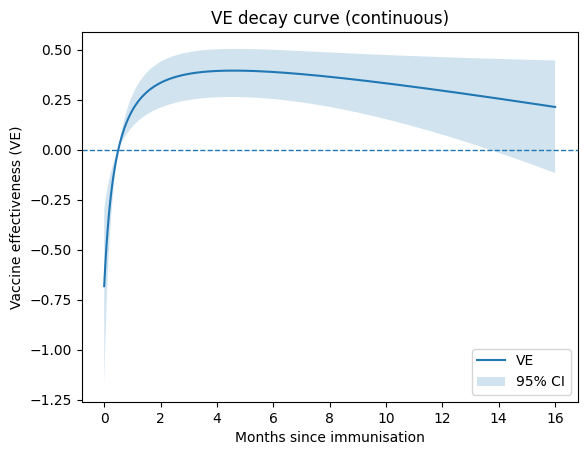

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- assumes you already fitted ctv and built terms/beta/Sigma as in your log(t) model ---
# terms = ["imm_logt"]  OR terms = ["imm_logt", "imm_logt_sq"]
# beta  = ctv.params_.loc[terms].to_numpy()
# Sigma = V.loc[terms, terms].to_numpy()

# Continuous grid in "months since immunisation"
m_grid = np.linspace(0, 16, 400)                 # 0..16 months
x = np.log(m_grid + 0.5)                         # log(t) with the same +0.5 convention

# Design matrix for the grid
if len(terms) == 1:
    Xg = x.reshape(-1, 1)                        # (400,1)
elif len(terms) == 2:
    Xg = np.column_stack([x, x**2])              # (400,2)
else:
    raise ValueError("terms must be length 1 (linear) or 2 (linear+quadratic).")

# logHR and SE via delta method
logHR_g = Xg @ beta
var_logHR_g = np.einsum("ij,jk,ik->i", Xg, Sigma, Xg)
se_logHR_g = np.sqrt(var_logHR_g)

zcrit = norm.ppf(0.975)
logHR_lo = logHR_g - zcrit * se_logHR_g
logHR_hi = logHR_g + zcrit * se_logHR_g

HR_g = np.exp(logHR_g)
HR_lo = np.exp(logHR_lo)
HR_hi = np.exp(logHR_hi)

VE_g = 1 - HR_g
VE_lo = 1 - HR_hi   # flip
VE_hi = 1 - HR_lo

# ---- Plot ----
plt.figure()
plt.plot(m_grid, VE_g, label="VE")
plt.fill_between(m_grid, VE_lo, VE_hi, alpha=0.2, label="95% CI")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Months since immunisation")
plt.ylabel("Vaccine effectiveness (VE)")
plt.title("VE decay curve (continuous)")
plt.legend()
plt.show()

In [218]:
df_tv_matched.columns

Index(['RUN', 'stop', 'event_vrs', 'start', 'inmunizado', 'inm_mayor_0_meses',
       'inm_mayor_1_meses', 'inm_mayor_2_meses', 'inm_mayor_3_meses',
       'inm_mayor_4_meses', 'inm_mayor_5_meses', 'inm_mayor_6_meses',
       'inm_mayor_7_meses', 'inm_mayor_8_meses', 'inm_mayor_9_meses',
       'inm_mayor_10_meses', 'inm_mayor_11_meses', 'inm_mayor_12_meses',
       'inm_mayor_13_meses', 'inm_mayor_14_meses', 'inm_mayor_15_meses',
       'inm_mayor_16_meses', 'group', 'eleg_2025', 'eleg_2024', 'eleg_group',
       'sexo', 'prematuro_extremo', 'muy_prematuro', 'prematuro_moderado',
       'prematuro', 'region', 'Macrozona2', 'EDAD_M', 'INS_C_M', 'REG_RES',
       'DIAG1', 'MARCA', 'PREVI', 'DIAG2', 'DIAG3', 'DIAG4', 'DIAG5', 'DIAG6',
       'DIAG7', 'DIAG8', 'DIAG9', 'DIAG10', 'DIAG11', 'URBA_RURAL', 'COMUNA',
       'COMUNA_N', 'atypic_mom_age', 'INS_N_M', 'SEMANAS', 'semana_nac',
       'mes_nac_name', 'year_nac', 'cama', 'is_rural', 'categori_macro',
       'categori_regions', 'exp_r

In [ ]:
event_col = "event_vrs"     # or "event_upc"
strata_col = "Group"      # <-- CHANGE THIS to your matched set id column

df_spline = df_tv_matched.copy()

K = 17
month_cols = [f"inm_mayor_{k}_meses" for k in range(K)]

M = df_spline[month_cols].fillna(0).astype(int).to_numpy()
has_month = M.sum(axis=1) > 0

k = (M * np.arange(K)).sum(axis=1).astype(float)
k[~has_month] = 0.0

# optional: use midpoints to avoid “knot at integers” feel (0.5, 1.5, ...)
df_spline["t_since_imm_m"] = k + 0.5

from sklearn.preprocessing import SplineTransformer
from scipy.stats import norm

n_knots = 6
degree = 3  # cubic

st = SplineTransformer(n_knots=n_knots, degree=degree, include_bias=False)

imm_mask = df_spline["inmunizado"].fillna(0).astype(int).to_numpy() == 1
st.fit(df_spline.loc[imm_mask, ["t_since_imm_m"]])

B = st.transform(df_spline[["t_since_imm_m"]])  # basis for all rows

# Add interaction columns: inmunizado * spline_j(t)
imm = df_spline["inmunizado"].fillna(0).astype(float).to_numpy()
for j in range(B.shape[1]):
    df_spline[f"imm_spl_{j}"] = imm * B[:, j]
    
spline_cols = [c for c in df_spline.columns if c.startswith("imm_spl_")]

# Minimal required columns:
base_cols = ["RUN", "start", "stop", event_col, strata_col]

X_cols = base_cols + spline_cols

ctv = CoxTimeVaryingFitter(penalizer=0.001)  # penalizer=0.01; small ridge often helps with spline stability
ctv.fit(
    df_spline[X_cols],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col=event_col,
    strata=[strata_col],
    show_progress=True
)

display(printSummary(ctv))


spline_cols = [c for c in ctv.params_.index if c.startswith("imm_spl_")]

# Rebuild variance matrix with proper labels (works even if lifelines returned RangeIndex)
V = ctv.variance_matrix_
V = pd.DataFrame(np.asarray(V), index=ctv.params_.index, columns=ctv.params_.index)

Sigma = V.loc[spline_cols, spline_cols].to_numpy()  # (J,J)
beta  = ctv.params_.loc[spline_cols].to_numpy()     # (J,)

months = np.arange(0, 17) + 0.5
B_grid = st.transform(months.reshape(-1, 1))  # (17, J)

logHR = B_grid @ beta

# Var(logHR_t) = b_t' Sigma b_t
var_logHR = np.einsum("ij,jk,ik->i", B_grid, Sigma, B_grid)
se_logHR = np.sqrt(var_logHR)

zcrit = norm.ppf(0.975)
logHR_lo = logHR - zcrit * se_logHR
logHR_hi = logHR + zcrit * se_logHR

HR = np.exp(logHR)
HR_lo = np.exp(logHR_lo)
HR_hi = np.exp(logHR_hi)

VE = 1 - HR
VE_lo = 1 - HR_hi   # flip because VE = 1 - HR
VE_hi = 1 - HR_lo

# Pointwise p-value at each month: H0: logHR(t)=0  (HR=1, VE=0)
z_month = logHR / se_logHR
p_month = 2 * (1 - norm.cdf(np.abs(z_month)))

ve_df = (pd.DataFrame({
            "MSI": (months - 0.5).astype(int),
            "p_value": np.where(p_month < 0.001, '<0.001', p_month.round(2).astype(str)),
            "VE": VE,
            "VE_95_low": VE_lo,
            "VE_95_up": VE_hi,
            "logHR": logHR,
            "SE_logHR": se_logHR,
            "z_month": z_month
        })
         .assign(Effectiveness = lambda x:(x["VE"].map("{:.2f}".format) + " ["+ x["VE_95_low"].map("{:.2f}".format) + ", " + x["VE_95_up"].map("{:.2f}".format)+ "]"))
         .drop(columns=['VE','VE_95_low','VE_95_up'])
)
ve_df[['MSI','Effectiveness'] + ve_df.columns[1:5].to_list()]


Iteration 1: norm_delta = 4.09e-01, step_size = 0.9500, log_lik = -535.10962, newton_decrement = 1.10e+02, seconds_since_start = 8.2
Iteration 2: norm_delta = 7.90e-02, step_size = 0.9500, log_lik = -420.48576, newton_decrement = 3.10e+00, seconds_since_start = 16.9
Iteration 3: norm_delta = 1.06e-02, step_size = 0.9500, log_lik = -417.27108, newton_decrement = 4.49e-02, seconds_since_start = 25.2
Iteration 4: norm_delta = 6.89e-04, step_size = 1.0000, log_lik = -417.22602, newton_decrement = 1.64e-04, seconds_since_start = 33.0
Iteration 5: norm_delta = 5.20e-07, step_size = 1.0000, log_lik = -417.22586, newton_decrement = 8.06e-11, seconds_since_start = 40.7
Convergence completed after 5 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
imm_spl_0,0.989032,0.844012,0.999229,8.634000e-04,-4.512801,1.354528,-7.167626,-1.857976
imm_spl_1,0.742335,0.572411,0.844731,2.000000e-07,-1.356095,0.258424,-1.862596,-0.849593
imm_spl_2,0.752010,0.625684,0.835703,0.000000e+00,-1.394367,0.210061,-1.806079,-0.982656
imm_spl_3,0.208419,-0.401062,0.552767,4.223665e-01,-0.233723,0.291308,-0.804676,0.337230
imm_spl_4,0.128803,-0.553516,0.511442,6.403292e-01,-0.137888,0.295112,-0.716296,0.440521
imm_spl_5,-0.123916,-0.865578,0.322897,6.513973e-01,0.116819,0.258551,-0.389932,0.623571
imm_spl_6,-0.151517,-1.067203,0.358558,6.365158e-01,0.141080,0.298534,-0.444036,0.726197


,MSI,Effectiveness,p_value,logHR,SE_logHR,z_month
0,0,"0.85 [0.77, 0.90]",<0.001,-1.888591,0.208999,-9.036370
1,1,"0.78 [0.72, 0.83]",<0.001,-1.534992,0.124681,-12.311384
2,2,"0.74 [0.68, 0.80]",<0.001,-1.359312,0.115462,-11.772857
3,3,"0.71 [0.63, 0.77]",<0.001,-1.227459,0.124131,-9.888389
4,4,"0.64 [0.53, 0.72]",<0.001,-1.022680,0.133563,-7.656905
5,5,"0.53 [0.36, 0.65]",<0.001,-0.756357,0.155501,-4.864001
6,6,"0.39 [0.13, 0.58]",0.01,-0.497303,0.184957,-2.688745
7,7,"0.27 [-0.07, 0.50]",0.11,-0.310769,0.193231,-1.608274
8,8,"0.19 [-0.18, 0.44]",0.28,-0.204679,0.190245,-1.075872
9,9,"0.13 [-0.27, 0.41]",0.47,-0.142824,0.196115,-0.728266


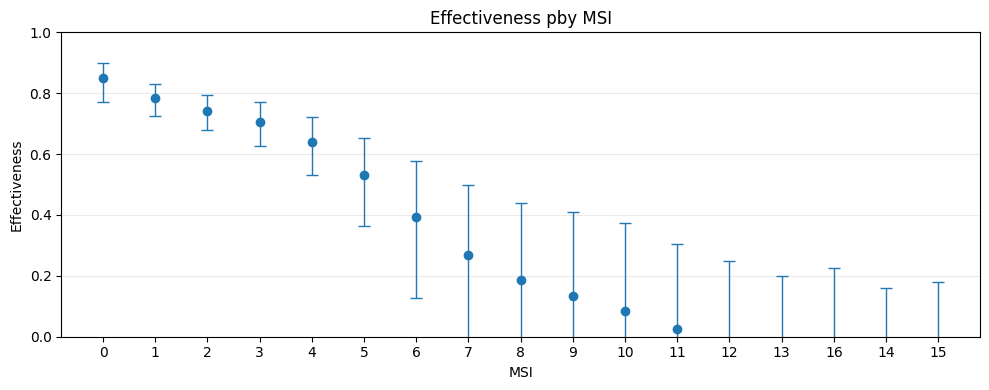

,MSI,p_value,VE,VE_95_low,VE_95_up,logHR,SE_logHR,z_month
0,0,<0.001,0.848715,0.772126,0.899563,-1.888591,0.208999,-9.036370
1,1,<0.001,0.784543,0.724901,0.831254,-1.534992,0.124681,-12.311384
2,2,<0.001,0.743163,0.677938,0.795178,-1.359312,0.115462,-11.772857
3,3,<0.001,0.706964,0.626249,0.770247,-1.227459,0.124131,-9.888389
4,4,<0.001,0.640370,0.532755,0.723200,-1.022680,0.133563,-7.656905
5,5,<0.001,0.530627,0.363379,0.653937,-0.756357,0.155501,-4.864001
6,6,0.01,0.391831,0.126104,0.576759,-0.497303,0.184957,-2.688745
7,7,0.11,0.267117,-0.070320,0.498171,-0.310769,0.193231,-1.608274
8,8,0.28,0.185091,-0.183166,0.438729,-0.204679,0.190245,-1.075872
9,9,0.47,0.133093,-0.273227,0.409746,-0.142824,0.196115,-0.728266


In [20]:
plot_df = (
    (pd.DataFrame({
            "MSI": (months - 0.5).astype(int),
            "p_value": np.where(p_month < 0.001, '<0.001', p_month.round(2).astype(str)),
            "VE": VE,
            "VE_95_low": VE_lo,
            "VE_95_up": VE_hi,
            "logHR": logHR,
            "SE_logHR": se_logHR,
            "z_month": z_month
        })
    )
    .sort_values("VE",ascending= False)
    )

# --- Plot ---
x = np.arange(len(plot_df))
y = plot_df["VE"].to_numpy()
yerr_low = y - plot_df["VE_95_low"].to_numpy()
yerr_up  = plot_df["VE_95_up"].to_numpy() - y
yerr = np.vstack([yerr_low, yerr_up])

fig, ax = plt.subplots(figsize=(10, 4))

ax.errorbar(
    x, y,
    yerr=yerr,
    fmt="o",
    capsize=4,
    linewidth=1
)

# opcional: unir puntos
# ax.plot(x, y)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["MSI"].tolist(), rotation=0)
ax.set_xlabel("MSI")
ax.set_ylabel("Effectiveness")
ax.set_title("Effectiveness pby MSI")
ax.grid(alpha=0.25, axis="y")

# Si quieres fijar el rango 0-1 (típico para efectividad)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

display(plot_df)


In [199]:
import numpy as np
import pandas as pd

def collapse_to_two_intervals(
    df: pd.DataFrame,
    id_col: str = "RUN",
    start_col: str = "start",
    stop_col: str = "stop",
    immun_col: str = "inmunizado",
    event_col: str = "event_vrs",
    strata_cols: list[str] | None = None,
    extra_static_cols: list[str] | None = None,
) -> pd.DataFrame:
    """
    Collapse an arbitrary split (multiple [start, stop) rows per id) into at most 2 intervals:
      - pre-immunisation (immun_col=0)
      - post-immunisation (immun_col=1), if immunisation occurs before end of follow-up

    Assumes event is indicated on the interval that ends at the event time (typical TV Cox format).
    """
    df = df.copy()

    # sanity
    for c in [start_col, stop_col]:
        if not np.issubdtype(df[c].dtype, np.number):
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df[immun_col] = df[immun_col].fillna(0).astype(int)
    df[event_col] = df[event_col].fillna(0).astype(int)

    if strata_cols is None:
        strata_cols = []

    # choose which columns to carry as "static"
    exclude = {start_col, stop_col, immun_col, event_col}
    if extra_static_cols is None:
        static_cols = [c for c in df.columns if c not in exclude]
    else:
        # keep only the columns you explicitly want (plus id/strata)
        static_cols = list(set([id_col] + strata_cols + extra_static_cols))

    # We'll take the first value within id for static cols (should be constant in your data)
    static = (
        df.sort_values([id_col, start_col])
          .groupby(id_col, as_index=False)[static_cols]
          .first()
    )

    rows = []
    for run, g in df.groupby(id_col, sort=False):
        g = g.sort_values(start_col)

        start0 = float(g[start_col].min())

        # event time = first stop where event==1 (if any); else censor time = max stop
        if (g[event_col] == 1).any():
            end_time = float(g.loc[g[event_col] == 1, stop_col].min())
            has_event = 1
        else:
            end_time = float(g[stop_col].max())
            has_event = 0

        # immunisation time = first time inmunizado becomes 1 (use min start among inmunizado==1)
        if (g[immun_col] == 1).any():
            imm_time = float(g.loc[g[immun_col] == 1, start_col].min())
        else:
            imm_time = None

        # helper to append a row if it has positive length
        def add_interval(a, b, imm, ev):
            if b is None or a is None:
                return
            if b <= a:
                return
            rows.append({
                id_col: run,
                start_col: a,
                stop_col: b,
                immun_col: int(imm),
                event_col: int(ev),
            })

        # Case 1: never immunised (or immunised after follow-up ends)
        if imm_time is None or imm_time >= end_time:
            add_interval(start0, end_time, imm=0, ev=has_event)
        else:
            # immunised before end of follow-up
            if has_event == 1 and end_time <= imm_time:
                # event happens before immunisation -> only pre interval ending at event
                add_interval(start0, end_time, imm=0, ev=1)
            else:
                # event (or censoring) after immunisation
                add_interval(start0, imm_time, imm=0, ev=0)
                add_interval(imm_time, end_time, imm=1, ev=has_event)

    out = pd.DataFrame(rows)
    out = out.merge(static, on=id_col, how="left")

    # reorder a bit
    front = [id_col] + (strata_cols if strata_cols else []) + [start_col, stop_col, immun_col, event_col]
    front = [c for c in front if c in out.columns]
    out = out[front + [c for c in out.columns if c not in front]].sort_values([id_col, start_col])

    return out

def split_immunised_in_d_days(
    df: pd.DataFrame,
    d: int,
    id_col: str = "RUN",
    start_col: str = "start",
    stop_col: str = "stop",
    immun_col: str = "inmunizado",
    event_col: str = "event_vrs",
) -> pd.DataFrame:
    """
    Split only immunised rows (immun_col==1) into consecutive intervals of length d (days).
    Keeps non-immunised rows as-is.

    Assumes event occurs at the end of follow-up interval (stop==event time).
    """
    if d <= 0:
        raise ValueError("d must be a positive integer (days).")

    rows = []
    for _, r in df.iterrows():
        a = float(r[start_col])
        b = float(r[stop_col])
        imm = int(r[immun_col])
        ev = int(r[event_col])

        if imm != 1 or (b - a) <= d:
            rows.append(r.to_dict())
            continue

        # split [a, b) into chunks of size d
        n_chunks = int(np.ceil((b - a) / d))
        for k in range(n_chunks):
            s = a + k * d
            t = min(a + (k + 1) * d, b)

            newr = r.to_dict()
            newr[start_col] = s
            newr[stop_col] = t

            # event only on the chunk that ends at b (if original had event)
            newr[event_col] = 1 if (ev == 1 and t == b) else 0
            rows.append(newr)

    out = pd.DataFrame(rows).sort_values([id_col, start_col]).reset_index(drop=True)
    return out

df_2int = collapse_to_two_intervals(
    df_tv_matched,
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    immun_col="inmunizado",
    event_col="event_vrs",      # o event_upc
    strata_cols=["Group"],      # mantiene tu estrato
)

df_2int_split = split_immunised_in_d_days(
    df_2int,
    d=14,                      # por ejemplo 7 días
    event_col="event_vrs",
)



In [200]:
event_col = "event_vrs"     # or "event_upc"
strata_col = "Group"      # <-- CHANGE THIS to your matched set id column

df_t_inm = df_2int_split.query('inmunizado==1').groupby('RUN',as_index=False).agg({'start':'min'}).rename(columns={'start':'t_inm'}).copy()

df_spline = df_2int_split.merge(df_t_inm[['RUN','t_inm']],how='left',on='RUN').copy()

df_spline["t_since_imm_m"] = (((df_spline['stop'] + df_spline['start'])/2) - df_spline['t_inm'])/14

df_spline.loc[df_spline.inmunizado==0, 't_since_imm_m'] = 0.0 

from sklearn.preprocessing import SplineTransformer
from scipy.stats import norm

n_knots = 6
degree = 3  # cubic

st = SplineTransformer(n_knots=n_knots, degree=degree, include_bias=False)

imm_mask = df_spline["inmunizado"].fillna(0).astype(int).to_numpy() == 1
st.fit(df_spline.loc[imm_mask, ["t_since_imm_m"]])

B = st.transform(df_spline[["t_since_imm_m"]])  # basis for all rows

# Add interaction columns: inmunizado * spline_j(t)
imm = df_spline["inmunizado"].fillna(0).astype(float).to_numpy()
for j in range(B.shape[1]):
    df_spline[f"imm_spl_{j}"] = imm * B[:, j]
    
spline_cols = [c for c in df_spline.columns if c.startswith("imm_spl_")]

# Minimal required columns:
base_cols = ["RUN", "start", "stop", event_col, strata_col]

X_cols = base_cols + spline_cols

ctv = CoxTimeVaryingFitter(penalizer=0.001)  # penalizer=0.01; small ridge often helps with spline stability
ctv.fit(
    df_spline[X_cols],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col=event_col,
    strata=[strata_col],
    show_progress=True
)

display(printSummary(ctv))


spline_cols = [c for c in ctv.params_.index if c.startswith("imm_spl_")]

# Rebuild variance matrix with proper labels (works even if lifelines returned RangeIndex)
V = ctv.variance_matrix_
V = pd.DataFrame(np.asarray(V), index=ctv.params_.index, columns=ctv.params_.index)

Sigma = V.loc[spline_cols, spline_cols].to_numpy()  # (J,J)
beta  = ctv.params_.loc[spline_cols].to_numpy()     # (J,)

months = np.arange(0, 17*2)
B_grid = st.transform(months.reshape(-1, 1))  # (17, J)

logHR = B_grid @ beta

# Var(logHR_t) = b_t' Sigma b_t
var_logHR = np.einsum("ij,jk,ik->i", B_grid, Sigma, B_grid)
se_logHR = np.sqrt(var_logHR)

zcrit = norm.ppf(0.975)
logHR_lo = logHR - zcrit * se_logHR
logHR_hi = logHR + zcrit * se_logHR

HR = np.exp(logHR)
HR_lo = np.exp(logHR_lo)
HR_hi = np.exp(logHR_hi)

VE = 1 - HR
VE_lo = 1 - HR_hi   # flip because VE = 1 - HR
VE_hi = 1 - HR_lo

# Pointwise p-value at each month: H0: logHR(t)=0  (HR=1, VE=0)
z_month = logHR / se_logHR
p_month = 2 * (1 - norm.cdf(np.abs(z_month)))

ve_df = (pd.DataFrame({
            "MSI": (months - 0.5).astype(int),
            "p_value": np.where(p_month < 0.001, '<0.001', p_month.round(2).astype(str)),
            "VE": VE,
            "VE_95_low": VE_lo,
            "VE_95_up": VE_hi,
            "logHR": logHR,
            "SE_logHR": se_logHR,
            "z_month": z_month
        })
         .assign(Effectiveness = lambda x:(x["VE"].map("{:.2f}".format) + " ["+ x["VE_95_low"].map("{:.2f}".format) + ", " + x["VE_95_up"].map("{:.2f}".format)+ "]"))
         .drop(columns=['VE','VE_95_low','VE_95_up'])
)
ve_df[['MSI','Effectiveness','p_value','logHR','SE_logHR','z_month']]


Iteration 1: norm_delta = 3.50e-01, step_size = 0.9500, log_lik = -535.10962, newton_decrement = 9.41e+01, seconds_since_start = 7.9
Iteration 2: norm_delta = 4.81e-02, step_size = 0.9500, log_lik = -438.42287, newton_decrement = 1.48e+00, seconds_since_start = 15.9
Iteration 3: norm_delta = 4.06e-03, step_size = 0.9500, log_lik = -436.92541, newton_decrement = 9.61e-03, seconds_since_start = 24.0
Iteration 4: norm_delta = 2.27e-04, step_size = 1.0000, log_lik = -436.91580, newton_decrement = 2.68e-05, seconds_since_start = 31.4
Iteration 5: norm_delta = 3.86e-08, step_size = 1.0000, log_lik = -436.91577, newton_decrement = 7.01e-13, seconds_since_start = 39.1
Convergence completed after 5 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
imm_spl_0,0.990797,0.838559,0.999475,0.001338,-4.688225,1.461561,-7.552831,-1.823618
imm_spl_1,0.678194,0.521645,0.783510,0.000000,-1.133808,0.202251,-1.530213,-0.737402
imm_spl_2,0.676740,0.559160,0.762960,0.000000,-1.129299,0.158282,-1.439526,-0.819072
imm_spl_3,0.218060,-0.175978,0.480067,0.237440,-0.245978,0.208207,-0.654056,0.162101
imm_spl_4,0.027560,-0.454905,0.350034,0.891856,-0.027947,0.205559,-0.430835,0.374941
imm_spl_5,-0.148704,-0.653745,0.202101,0.455882,0.138635,0.185926,-0.225773,0.503042
imm_spl_6,0.012809,-0.829959,0.467449,0.967344,-0.012892,0.314896,-0.630077,0.604294


,MSI,Effectiveness,p_value,logHR,SE_logHR,z_month
0,0,"0.82 [0.72, 0.89]",<0.001,-1.725459,0.233822,-7.379376
1,0,"0.78 [0.70, 0.84]",<0.001,-1.531203,0.168618,-9.080876
2,1,"0.75 [0.68, 0.80]",<0.001,-1.378112,0.126220,-10.918362
3,2,"0.72 [0.65, 0.77]",<0.001,-1.265037,0.104478,-12.108139
4,3,"0.69 [0.63, 0.75]",<0.001,-1.182646,0.096105,-12.305819
5,4,"0.67 [0.61, 0.73]",<0.001,-1.121608,0.094408,-11.880394
6,5,"0.66 [0.59, 0.72]",<0.001,-1.072589,0.095602,-11.219368
7,6,"0.64 [0.57, 0.70]",<0.001,-1.026256,0.097973,-10.474903
8,7,"0.62 [0.54, 0.69]",<0.001,-0.973288,0.100445,-9.689740
9,8,"0.60 [0.51, 0.67]",<0.001,-0.907634,0.102566,-8.849295


In [ ]:
(df
 .query('inmunizado==0')
 .query('event_vrs==1')
 .assign(mes_ing = lambda x: x.fechaIng_vrs.dt.month_name(),
         ano_ing = lambda x: x.fechaIng_vrs.dt.year)
 .query('fechaIng_vrs >= "2024-10-01"')
 .groupby(['mes_ing','ano_ing','eleg_2025'])
 .RUN.count()
 .unstack(['eleg_2025'])
 .fillna(0) 
 .sum()
 )

,eleg_2025,CATCH_UP,SEASONAL,no_elegible_2025
mes_ing,ano_ing,,,
April,2025,19.0,0.0,1.0
August,2025,17.0,8.0,23.0
December,2024,9.0,0.0,2.0
February,2025,16.0,0.0,0.0
January,2025,16.0,0.0,0.0
July,2025,20.0,10.0,22.0
June,2025,30.0,4.0,16.0
March,2025,32.0,0.0,1.0
May,2025,5.0,3.0,4.0


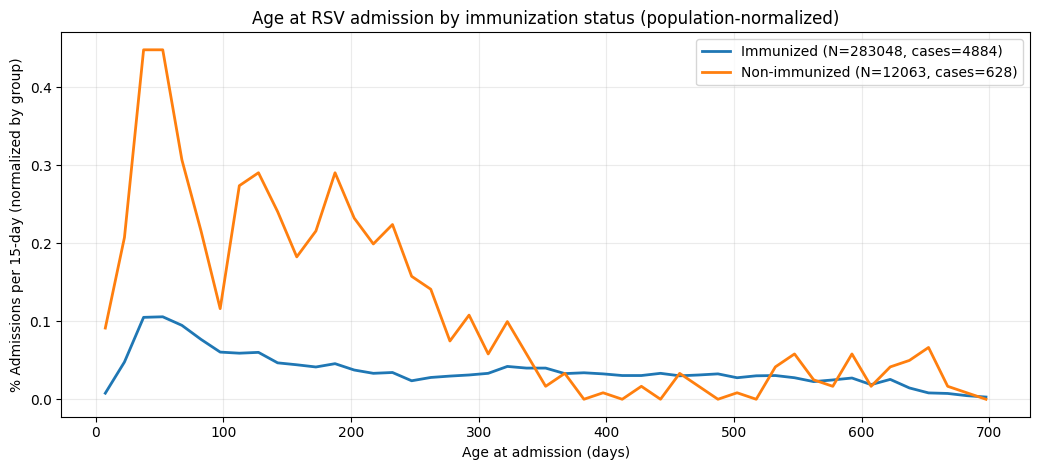

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# df: 1 fila por infante, con fecha_nac, fechaIng_vrs, fechaInm (NaT si nunca), o tu columna inmunizado (0/1)
dfp = df.copy()

# --- define "ever immunized" ---
# si ya tienes dfp["inmunizado"] 0/1, úsalo directamente:
if "inmunizado" not in dfp.columns:
    dfp["inmunizado"] = dfp["fechaInm"].notna().astype(int)

# --- age at admission (days) solo para quienes tienen ingreso VRS ---
dfp["fecha_nac"] = pd.to_datetime(dfp["fecha_nac"], errors="coerce")
dfp["fechaIng_vrs"] = pd.to_datetime(dfp["fechaIng_vrs"], errors="coerce")

df_evt = dfp[dfp["fechaIng_vrs"].notna()].copy()
df_evt["age_at_adm_days"] = (df_evt["fechaIng_vrs"] - df_evt["fecha_nac"]).dt.days

# sacar edades negativas o absurdas
# df_evt = df_evt[df_evt["age_at_adm_days"].between(0, 365*2)]  # ajusta si quieres

# --- denominadores poblacionales (para normalizar a la población de cada grupo) ---
N_imm = int((dfp["inmunizado"] == 1).sum())
N_no  = int((dfp["inmunizado"] == 0).sum())

# --- construir histogramas normalizados a población: "casos por bin / población del grupo" ---
bin_width = 15  # días por bin (semanal). Cambia a 14/30 si quieres.
max_age = int(df_evt["age_at_adm_days"].max())
bins = np.arange(0, max_age + bin_width, bin_width)

ages_imm = df_evt.loc[df_evt["inmunizado"] == 1, "age_at_adm_days"].to_numpy()
ages_no  = df_evt.loc[df_evt["inmunizado"] == 0, "age_at_adm_days"].to_numpy()

h_imm, _ = np.histogram(ages_imm, bins=bins)
h_no,  _ = np.histogram(ages_no,  bins=bins)

# tasa por bin (proporción de la población que tuvo admisión en ese bin)
rate_imm = h_imm*100 / N_imm if N_imm > 0 else np.zeros_like(h_imm, dtype=float)
rate_no  = h_no*100  / N_no  if N_no  > 0 else np.zeros_like(h_no, dtype=float)

# eje x = centro del bin
x = (bins[:-1] + bins[1:]) / 2

# --- plot ---
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.plot(x, rate_imm, linewidth=2, label=f"Immunized (N={N_imm}, cases={len(ages_imm)})")
ax.plot(x, rate_no,  linewidth=2, label=f"Non-immunized (N={N_no}, cases={len(ages_no)})")

ax.set_xlabel("Age at admission (days)")
ax.set_ylabel(f"% Admissions per {bin_width}-day (normalized by group)")
ax.set_title("Age at RSV admission by immunization status (population-normalized)")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

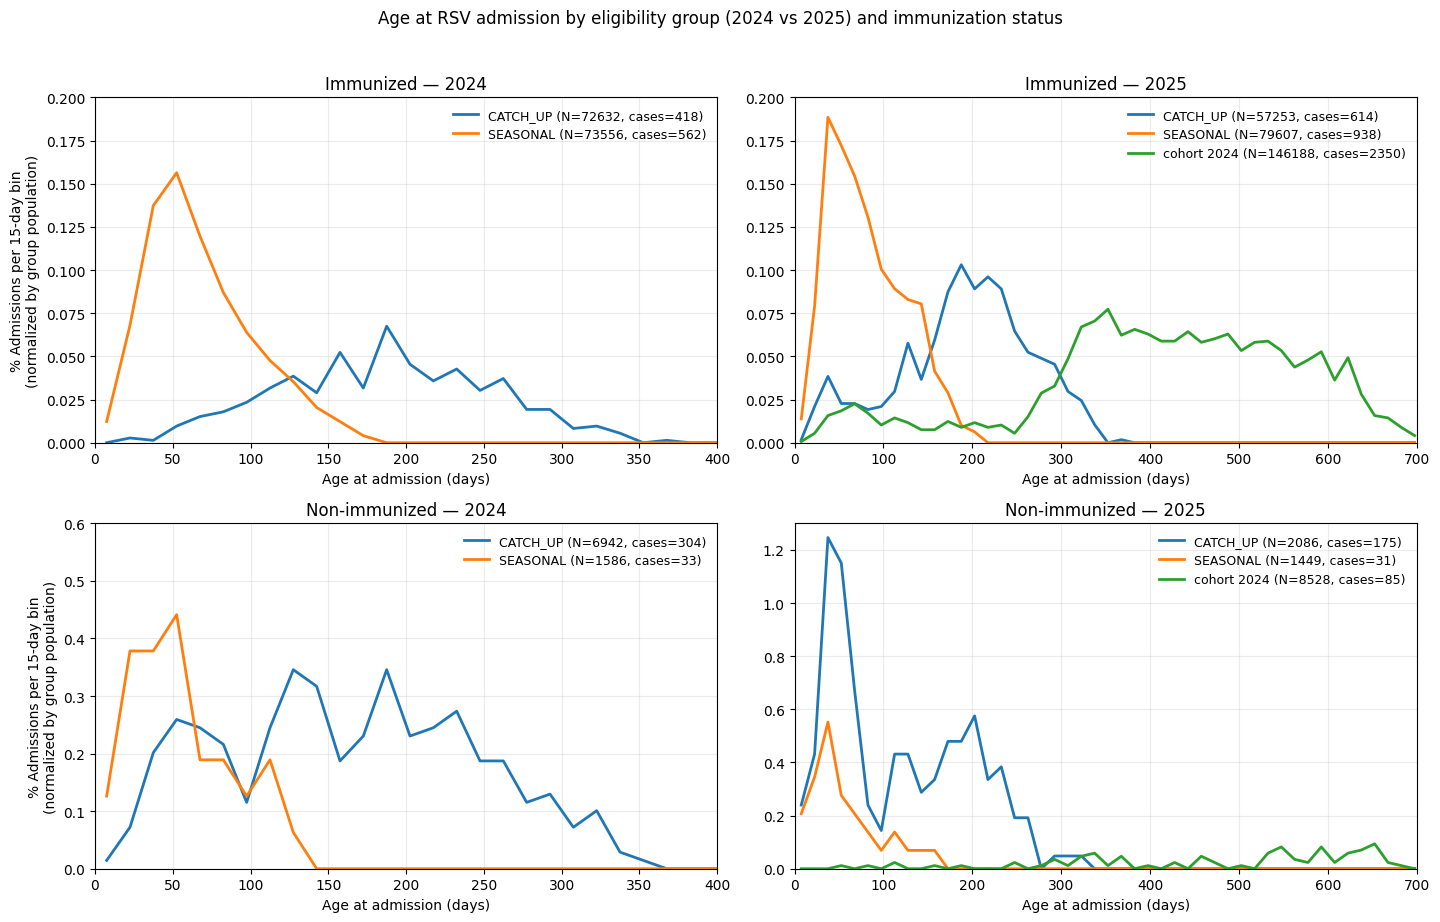

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfp = df.copy()

dfp["fecha_nac"] = pd.to_datetime(dfp["fecha_nac"], errors="coerce")
dfp["fechaIng_vrs"] = pd.to_datetime(dfp["fechaIng_vrs"], errors="coerce")

if "inmunizado" not in dfp.columns:
    dfp["inmunizado"] = dfp["fechaInm"].notna().astype(int)
else:
    dfp["inmunizado"] = dfp["inmunizado"].astype(int)

def clean_eleg(s):
    s = s.astype(str).str.strip().str.upper()
    s = s.replace({
        "CATCHUP": "CATCH_UP",
        "CATCH UP": "CATCH_UP",
        "SEASONAL": "SEASONAL",
        "NO_ELEGIBLE": "NO_ELEGIBLE",
        "NO_ELEGIBLE_2024": "NO_ELEGIBLE_2024",
        "NO_ELEGIBLE_2025": "NO_ELEGIBLE_2025",
        "NAN": np.nan,
        "NONE": np.nan
    })
    return s

dfp["eleg_2024"] = clean_eleg(dfp["eleg_2024"])
dfp["eleg_2025"] = clean_eleg(dfp["eleg_2025"])

# Cases only for age-at-admission (sin filtro temporal aún)
df_evt = dfp[dfp["fechaIng_vrs"].notna()].copy()
df_evt["age_at_adm_days"] = (df_evt["fechaIng_vrs"] - df_evt["fecha_nac"]).dt.days
df_evt = df_evt[df_evt["age_at_adm_days"].between(0, 700)].copy()

bin_width = 15
max_age = int(df_evt["age_at_adm_days"].max())
bins = np.arange(0, max_age + bin_width, bin_width)
x = (bins[:-1] + bins[1:]) / 2

# Cortes de tiempo
cut_2024_start = pd.Timestamp("2023-10-01")
cut_2024_end   = pd.Timestamp("2024-10-01")  # exclusivo (hasta Sep-24 inclusive)
cut_post_2024  = pd.Timestamp("2024-10-01")  # >= Oct-24

mask_evt_2024 = (df_evt["fechaIng_vrs"] >= cut_2024_start) & (df_evt["fechaIng_vrs"] < cut_2024_end)
mask_evt_post = (df_evt["fechaIng_vrs"] >= cut_post_2024)

def rate_curve(inm_val, group_col, group_val, mask_evt):
    # denominator: all infants in that inmunizado x group_val (population)
    N = int(dfp.loc[(dfp["inmunizado"] == inm_val) & (dfp[group_col] == group_val), "RUN"].nunique())

    sub = df_evt.loc[
        mask_evt
        & (df_evt["inmunizado"] == inm_val)
        & (df_evt[group_col] == group_val),
        "age_at_adm_days"
    ].to_numpy()

    h, _ = np.histogram(sub, bins=bins)
    rate = h*100 / N if N > 0 else np.zeros_like(h, dtype=float)
    return rate, N, len(sub)

fig, axes = plt.subplots(2, 2, figsize=(14.5, 9), sharex=False, sharey=False)

groups_24 = ["CATCH_UP", "SEASONAL"]
groups_25 = ["CATCH_UP", "SEASONAL", "NO_ELEGIBLE_2025"]
label_map_25 = {"NO_ELEGIBLE_2025": "cohort 2024"}

panels = [
    # row, col, inm_val, group_col, groups, title, mask_evt
    (0, 0, 1, "eleg_2024", groups_24, "Immunized — 2024",     mask_evt_2024),
    (1, 0, 0, "eleg_2024", groups_24, "Non-immunized — 2024", mask_evt_2024),

    # Para panel 2025: usar eventos post Sep-24 (>= Oct-24)
    (0, 1, 1, "eleg_2025", groups_25, "Immunized — 2025",     mask_evt_post),
    (1, 1, 0, "eleg_2025", groups_25, "Non-immunized — 2025", mask_evt_post),
]

for r, c, inm_val, gcol, groups, title, mask_evt in panels:
    ax = axes[r, c]
    for g in groups:
        # regla extra explícita (por si quieres que SOLO "cohort 2024" use post-2024, y las otras no):
        # if (gcol == "eleg_2025") and (g == "NO_ELEGIBLE_2025"):
        #     mask_use = mask_evt_post
        # else:
        #     mask_use = mask_evt
        mask_use = mask_evt  # como pediste, 2025 usa post Sep-24

        rate, N, n_cases = rate_curve(inm_val, gcol, g, mask_use)
        g_lab = label_map_25.get(g, g)
        ax.plot(x, rate, linewidth=2, label=f"{g_lab} (N={N}, cases={n_cases})")

    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.set_xlabel("Age at admission (days)")
    ax.legend(fontsize=9, frameon=False, loc="upper right")

axes[0, 0].set_ylabel(f"% Admissions per {bin_width}-day bin\n(normalized by group population)")
axes[1, 0].set_ylabel(f"% Admissions per {bin_width}-day bin\n(normalized by group population)")

axes[0, 0].set_ylim(0, 0.2)
axes[0, 1].set_ylim(0, 0.2)
axes[1, 0].set_ylim(0, 0.6)
axes[1, 1].set_ylim(0, 1.3)

axes[0, 0].set_xlim(0, 400)
axes[1, 0].set_xlim(0, 400)

# 2025 panels (col 1)
axes[0, 1].set_xlim(0, 700)
axes[1, 1].set_xlim(0, 700)

fig.suptitle("Age at RSV admission by eligibility group (2024 vs 2025) and immunization status", y=1.02)
plt.tight_layout()
plt.show()